## Author: Gabriel Vance
## Class: DSC630 - Predictive Analytics
## Professor: Professor Andrew Hua
## Date: September 14, 2025

# Purpose: This notebook performs the tasks outlined in 1.2 Assignment: R/Python Refresher.

### 1. Write a summary of your data and identify at least two questions to explore visually with your data.

I want to visualize the differences in survivorship by gender and age on the Titanic. It's widely known that "women and children" were given priority for lifeboats in the titanic. We will tell the story of survivorship on the Titanic to visualize the results. Ultimately, we will conclude whether or not women and children survived at a higher rate. Bar charts will be used to visualize the results, with the Y axis representing the survival rate and the X axis representing the different groups.

* Question 1: What is the overall survival rate on the Titanic?
* Question 2: How does the survival rate differ by gender?
* Question 3: How does the survival rate differ by age group?
* Question 4: Did women and children survive at a higher rate?

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Ensure that all code cells are fully visible without scrolling
from IPython.core.display import display, HTML

display(HTML('''
<style>
div.CodeMirror pre {
    white-space: pre !important;
}
</style>
'''))

In [2]:
# Load the datasets df['Survived'] has binary values
# 1 = the passenger survived
# 0 = the passenger did not survive
df = pd.read_csv('train.csv') 


print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### 2. Create a histogram or bar graph from your data.

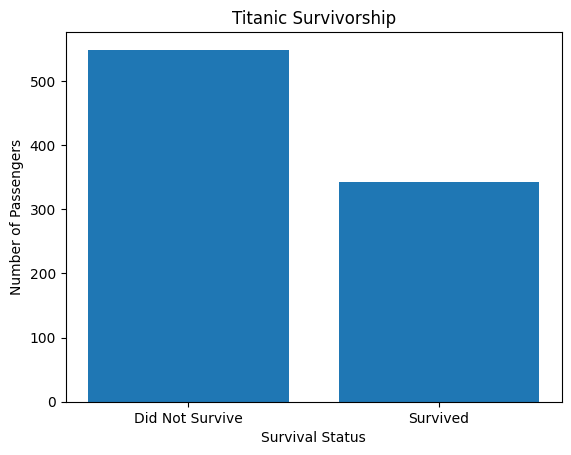

In [3]:
# We'll first visualize the overall count of survivors vs non-survivors
survival_counts = df['Survived'].value_counts().sort_index()
plt.bar(['Did Not Survive', 'Survived'], survival_counts)
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')
plt.title('Titanic Survivorship')
plt.show()

Classes are imbalanced. There are more passengers that did not survive than those that did. Overall survive rate is 38.38%.

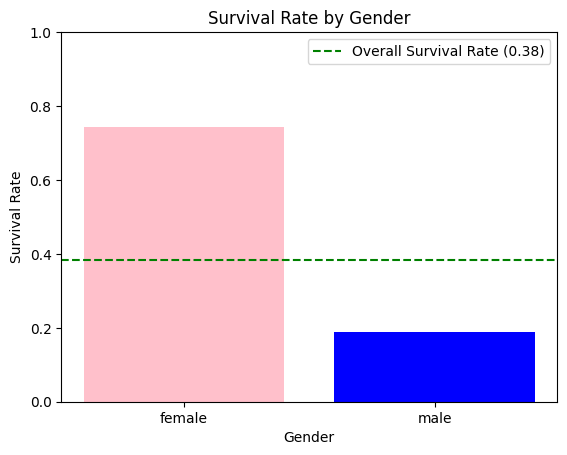

In [4]:
# Plot male vs female survivorship
gender_survival = df.groupby('Sex')['Survived'].mean()
overall_survival_rate = df['Survived'].mean()
plt.bar(gender_survival.index, gender_survival.values, color=['pink', 'blue'])
plt.axhline(overall_survival_rate, color='green', linestyle='--', label=f'Overall Survival Rate ({overall_survival_rate:.2f})')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Gender')
plt.ylim(0, 1)
plt.legend()
plt.show()

In [5]:
print(f"Overall Survival Rate: {overall_survival_rate:.2%}")

Overall Survival Rate: 38.38%


In [6]:
# Print survival rates by male and female
print("Survival Rate by Gender:")
for gender, rate in gender_survival.items():
    print(f"{gender.capitalize()}: {rate:.2%}")

Survival Rate by Gender:
Female: 74.20%
Male: 18.89%


Females generally survived at a much higher rate.

### 3. Create a boxplot from your data.

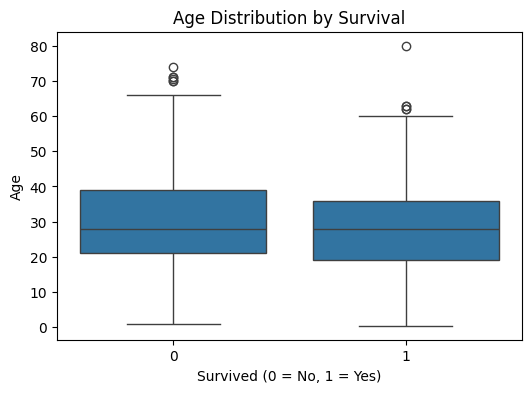

In [7]:
# Create a boxplot: Age vs. Survival
plt.figure(figsize=(6, 4))
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

The distribution of ages is similar between those that survived and those that did not. The median age of those that survived is slightly lower than those that did not survive. We will further explore age by creating age groups.

### 4. Create a bivariate plot from your data.

In [8]:
print(f"Minimum Age: {df['Age'].min()}")
print(f"Maximum Age: {df['Age'].max()}")

Minimum Age: 0.42
Maximum Age: 80.0


In [9]:
# 1. Standard life stages
# 0–12   : Children
# 13–19  : Teenagers
# 20–29  : Young Adults
# 30–39  : Adults
# 40–49  : Middle-aged Adults
# 50–64  : Older Adults
# 65–80  : Seniors

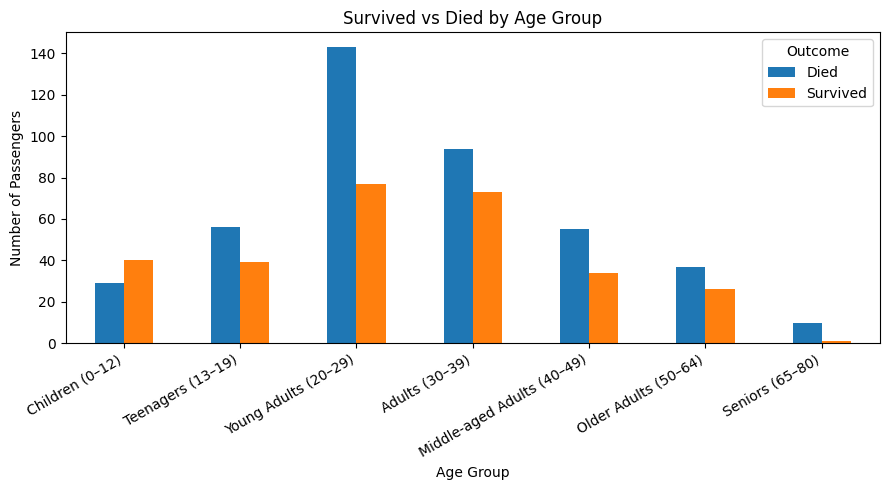

In [10]:
# Define age bins
age_bins = [0, 12, 19, 29, 39, 49, 64, 80]

# Create labels with ranges
age_labels = [
    "Children (0–12)",
    "Teenagers (13–19)",
    "Young Adults (20–29)",
    "Adults (30–39)",
    "Middle-aged Adults (40–49)",
    "Older Adults (50–64)",
    "Seniors (65–80)"
]

# Make new column for age groups
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, right=True)

# Drop rows with missing Age
df_agegroup = df.dropna(subset=["AgeGroup"])

# Count survived/died per age group
agegroup_counts = (
    df_agegroup.groupby(["AgeGroup", "Survived"])
    .size()
    .unstack(fill_value=0)
    .reindex(age_labels)  # keep logical order
)

# Plot
ax = agegroup_counts.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Passengers")
ax.set_title("Survived vs Died by Age Group")
ax.legend(["Died", "Survived"], title="Outcome")
plt.xticks(rotation=30, ha="right")  # tilt labels for readability
plt.tight_layout()
plt.show()


### 5. Create any additional visualizations that will help to answer the question(s) you want to answer.


In [11]:
# Mean survival rate per age group 
agegroup_survival_rate = (
    df_agegroup.groupby("AgeGroup")["Survived"]
    .mean()
    .reindex(age_labels)
)

agegroup_survival_table = (
    agegroup_survival_rate.rename("Mean Survival Rate (%)")
    .mul(100)
    .round(2)
    .reset_index()
)
agegroup_survival_table.columns = ["Age Group", "Mean Survival Rate (%)"]

# Add percent delta to overall survival rate
overall_survival_rate_percent = overall_survival_rate * 100
agegroup_survival_table["Delta to Overall (%)"] = (
    agegroup_survival_table["Mean Survival Rate (%)"] - overall_survival_rate_percent
).round(2)

# Print results
print(
    agegroup_survival_table.to_string(
        index=False,
        formatters={
            "Mean Survival Rate (%)": "{:.2f}%".format,
            "Delta to Overall (%)": lambda x: f"{x:+.2f}%"
        }
    )
)

                 Age Group Mean Survival Rate (%) Delta to Overall (%)
           Children (0–12)                 57.97%              +19.59%
         Teenagers (13–19)                 41.05%               +2.67%
      Young Adults (20–29)                 35.00%               -3.38%
            Adults (30–39)                 43.71%               +5.33%
Middle-aged Adults (40–49)                 38.20%               -0.18%
      Older Adults (50–64)                 41.27%               +2.89%
           Seniors (65–80)                  9.09%              -29.29%


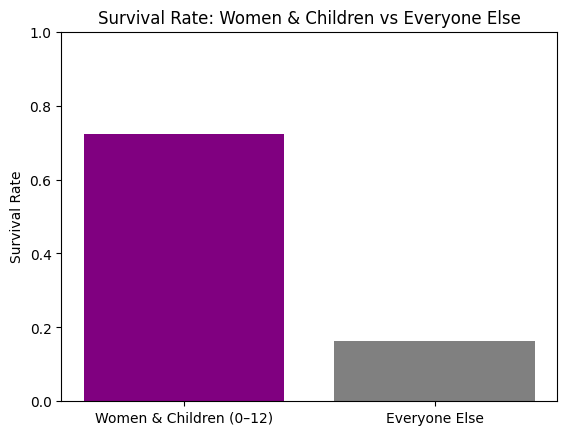

In [12]:
# Create a mask for women and children (age 0-12)
women_mask = df['Sex'] == 'female'
children_mask = df['AgeGroup'] == 'Children (0–12)'

# Group 1: Women and Children (0–12)
group1_mask = women_mask | children_mask
group1_survival_rate = df.loc[group1_mask, 'Survived'].mean()

# Group 2: Everyone else
group2_mask = ~group1_mask
group2_survival_rate = df.loc[group2_mask, 'Survived'].mean()

# Prepare data for bar chart
groups = ['Women & Children (0–12)', 'Everyone Else']
rates = [group1_survival_rate, group2_survival_rate]

plt.bar(groups, rates, color=['purple', 'gray'])
plt.ylabel('Survival Rate')
plt.title('Survival Rate: Women & Children vs Everyone Else')
plt.ylim(0, 1)
plt.show()

In [13]:
print(f"Survival Rate (Women & Children 0–12): {group1_survival_rate:.2%}")
print(f"Survival Rate (Everyone Else): {group2_survival_rate:.2%}")

Survival Rate (Women & Children 0–12): 72.36%
Survival Rate (Everyone Else): 16.30%


### 6. Summarize your results and make a conclusion. Explain how you arrived at this conclusion and how your visualizations support your conclusion.


* Question 1: What is the overall survival rate on the Titanic? 
  - Overall survival rate is 38.38%.
* Question 2: How does the survival rate differ by gender?
Survival rate by gender is as follows:
  - Female: 74.2%
  - Male: 18.9%
* Question 3: How does the survival rate differ by age group?
Survival rate by age group is as follows (rate and difference from overall rate):
  - Children (0–12): 57.97% (+19.59%)
  - Teenagers (13–19): 41.05% (+2.67%)
  - Young Adults (20–29): 35.00% (-3.38%)
  - Adults (30–39): 43.71% (+5.33%)
  - Middle-aged Adults (40–49): 38.20% (-0.18%)
  - Older Adults (50–64): 41.27% (+2.89%)
  - Seniors (65–80): 9.09% (-29.29%)


Conclusions: On average, the survival rate was only 38.38%. The female survive rate was almost exactly double the normal survival rate and men survived at only half the normal survival rate. Children had the highest survival rate of all age groups at 57.97%. Seniors had the lowest survival rate at only 9.09%. 

* Question 4: Did women and children survive at a higher rate?
  - Yes, women and children (0–12) survived at a higher rate compared to everyone else. The survival rate for women and children was 72.36%, while the survival rate for everyone else was only 16.30%. This can easily be discerned by comparing the surival rate of women and children vs everyone else.

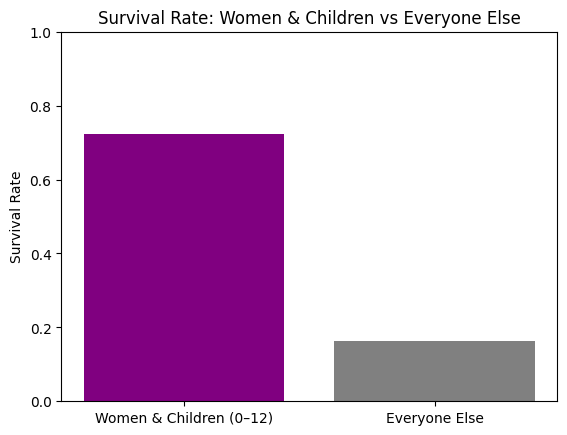